# Tilt series generator

This notebook simulates a full cryoET tilt series end to end, matching the pipeline in
[`dev/cryoet-specimen-generation/10440.ipynb`](../../dev/cryoet-specimen-generation/10440.ipynb):

1. **Placement** — `specter.specimen.CryoETSpecimenGenerator` runs `polnet`'s non-overlapping,
   occupancy-driven packing of proteins + membranes, then renders the real high-resolution
   scattering potential directly (one atomic potential per protein species, an analytic
   bilayer per membrane).
2. **Acquisition** — `TiltSeriesGenerator` blends in amorphous ice, then simulates the tilted
   acquisition: multislice scattering per tilt angle, CTF, dose, detector MTF, and Poisson
   shot noise.

All of the parameters that control the simulation live in
[`tilt_series.toml`](./tilt_series.toml), loaded by the second cell via
`load_config("tilt_series.toml", TiltSeriesConfig)` — **edit that file, not this notebook**, to
change what gets generated.

## Editing `tilt_series.toml`

| Section | Controls |
|---|---|
| `[[protein_specs]]` | One table per protein species — `PDB_CODE` required, `PMER_OCC` etc. optional (see `CryoETSpecimenGenerator`'s docstring) |
| `[[membrane_specs]]` | One table per membrane species/population (polnet `.mbs`-equivalent keys) |
| `[specimen]` | Filler occupancy, target volume shape/voxel size, placement-pass resolution, seed |
| `[microscope]` | Accelerating voltage, dose per tilt, spherical aberration (`cs`), amplitude contrast (`alpha`) |
| `[defocus]` | Defocus (Å) |
| `[tilt_geometry]` | Tilt angle range, number of tilts, tilt axis |
| `[models]` | Which physics models to use (scattering, aberration, noise, ice, detector) |
| `[compute]` | Device (`cuda:0`, `cpu`, ...) |

A commented-out line means that field is left at its `TiltSeriesConfig` default — see
[`configs/tilt_series.toml`](../../configs/tilt_series.toml) for the full/canonical set of
available fields and defaults, and [`src/specter/config.py`](../../src/specter/config.py) for
authoritative types/units. This notebook's own `tilt_series.toml` uses a deliberately small
specimen/tilt scheme so it finishes in a few minutes — see the "Notes for scaling up" section
of `10440.ipynb` before going to production size.

**Compute cost warning**: multislice propagation cost scales with slice count × XY size × number
of tilts, so production-size runs (e.g. `target_shape=(736, 2520, 2520)`) can take a while (many
minutes to longer).

After editing the TOML file, re-run the notebook from the top (or just re-run the
`load_config(...)` cell and everything below it) to pick up the new values.

In [25]:
import logging
import time

import matplotlib.pyplot as plt
import torch

import specter
from specter.config import load_config, TiltSeriesConfig
from specter.plots import plot3d, plot_particle_stack
from specter.specimen.cryoet import CryoETSpecimenGenerator
from specter.specimen.cytosolic_filler import build_filler_protein_specs
from specter.imagegenerator import TiltSeriesGenerator

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
config = load_config("tilt_series.toml", TiltSeriesConfig)

In [3]:
specter.set_verbosity(logging.INFO)

## Configure and place the specimen

`protein_specs`/`membrane_specs` come straight from `tilt_series.toml`'s `[[protein_specs]]`/
`[[membrane_specs]]` tables. If `filler_occupancy` is set, generic cytosolic filler (a published
crowded-cytoplasm reference set, see `build_filler_protein_specs`'s docstring) is appended to
avoid an unrealistically empty/flat background around the annotated targets.

`target_shape`/`target_v_size` (under `[specimen]`) is the real output volume, `(Z, Y, X)`
voxels at the given Å/voxel; `low_res_v_size` is the voxel size `polnet` uses for its placement
pass (10 Å is a good default — fast, and the analytic membrane/rotation math doesn't care about
this resolution at all).

In [4]:
protein_specs = list(config.protein_specs)
if config.filler_occupancy is not None:
    protein_specs += build_filler_protein_specs(total_occupancy=config.filler_occupancy)

gen = CryoETSpecimenGenerator(
    protein_specs=protein_specs,
    membrane_specs=config.membrane_specs,
    target_shape=tuple(config.target_shape),
    target_v_size=config.target_v_size,
    low_res_v_size=config.low_res_v_size,
    pdb_cache_dir=config.pdb_savefolder,
    membrane_potential_scale=config.membrane_potential_scale,
    seed=config.seed,
)

## Generate

Runs `polnet`'s placement at low resolution, then renders the real high-resolution volume.
Returns a `torch.Tensor`, specter-native axis order `(Z, Y, X)`.

In [5]:
t0 = time.time()
volume = gen.generate()
print(f"generated in {time.time() - t0:.1f}s")
print(
    "shape:",
    tuple(volume.shape),
    "nonzero voxels:",
    int((volume > 0).sum()),
    "max:",
    float(volume.max()),
)

[cryoet] low-res placement: (128, 128, 46) voxels @ 10.0 A/vx, 26 protein species, 1 membrane spec(s)


[14:11:35] INFO: Inserted 1 membranes of type 'sphere' with occupancy 5.2917 %.


[cryoet]   7VD8: 36713 atoms, low-res placeholder built in 5.2s
[cryoet]   6QZP: 219463 atoms, low-res placeholder built in 10.7s
[cryoet]   7B75: 39122 atoms, low-res placeholder built in 3.6s
[cryoet]   6N4V: 236760 atoms, low-res placeholder built in 10.3s
[cryoet]   6DRV: 32888 atoms, low-res placeholder built in 3.4s
[cryoet]   1FA2: 16288 atoms, low-res placeholder built in 3.0s
[cryoet]   1A1S: 29448 atoms, low-res placeholder built in 3.3s
[cryoet]   1EQR: 19103 atoms, low-res placeholder built in 3.4s
[cryoet]   1GYT: 24988 atoms, low-res placeholder built in 4.1s
[cryoet]   1KYI: 45756 atoms, low-res placeholder built in 5.0s
[cryoet]   1VPX: 16267 atoms, low-res placeholder built in 3.7s
[cryoet]   1W6T: 28516 atoms, low-res placeholder built in 3.8s
[cryoet]   2BYU: 9648 atoms, low-res placeholder built in 2.7s
[cryoet]   2GLS: 43692 atoms, low-res placeholder built in 4.2s
[cryoet]   2IDB: 22236 atoms, low-res placeholder built in 3.6s
[cryoet]   3DY4: 50588 atoms, low-res

[14:13:23] INFO: No 6N4V proteins generated.


[cryoet] polnet protein packing done in 1.7s
[cryoet] 39 protein instance(s) placed
[cryoet]   chain sizes (SAWLC): 7VD8: {2: 1}; 6QZP: {1: 1}; 7B75: {1: 1}; 6DRV: {1: 1}; 1FA2: {2: 1}; 1A1S: {2: 1}; 1EQR: {2: 1}; 1GYT: {2: 1}; 1KYI: {2: 1}; 1VPX: {2: 1}; 1W6T: {1: 1}; 2BYU: {1: 1}; 2GLS: {2: 1}; 2IDB: {1: 1}; 3DY4: {1: 1}; 1BXR: {1: 1}; 1F1B: {2: 1}; 1KP8: {2: 1}; 1QO1: {1: 1}; 1VRG: {2: 1}; 1YG6: {2: 1}; 2BO9: {2: 1}; 2GHO: {1: 1}; 2H12: {1: 1}; 2REC: {2: 1}
[cryoet] 1 membrane instance(s) fitted
[cryoet] high-res assembly: (92, 256, 256) voxels @ 5.0 A/vx
[cryoet]   1A1S: high-res potential (30^3 @ 5.0 A/vx) built in 0.2s
[cryoet]   1BXR: high-res potential (52^3 @ 5.0 A/vx) built in 0.4s
[cryoet]   1EQR: high-res potential (46^3 @ 5.0 A/vx) built in 0.3s
[cryoet]   1F1B: high-res potential (32^3 @ 5.0 A/vx) built in 0.3s
[cryoet]   1FA2: high-res potential (30^3 @ 5.0 A/vx) built in 0.2s
[cryoet]   1GYT: high-res potential (32^3 @ 5.0 A/vx) built in 0.3s
[cryoet]   1KP8: high-res p

## Visualize

Central slice through Z, and a 3D rendering.

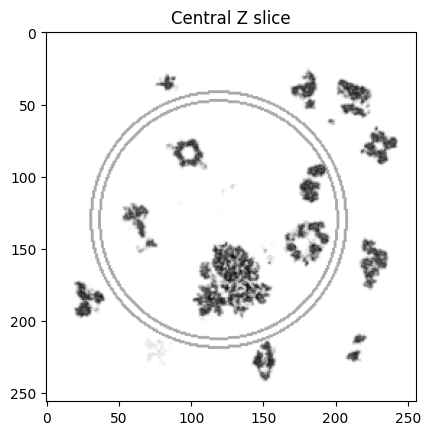

In [6]:
plt.imshow(-volume[volume.shape[0] // 2], cmap="grey")
plt.title("Central Z slice")
plt.show()

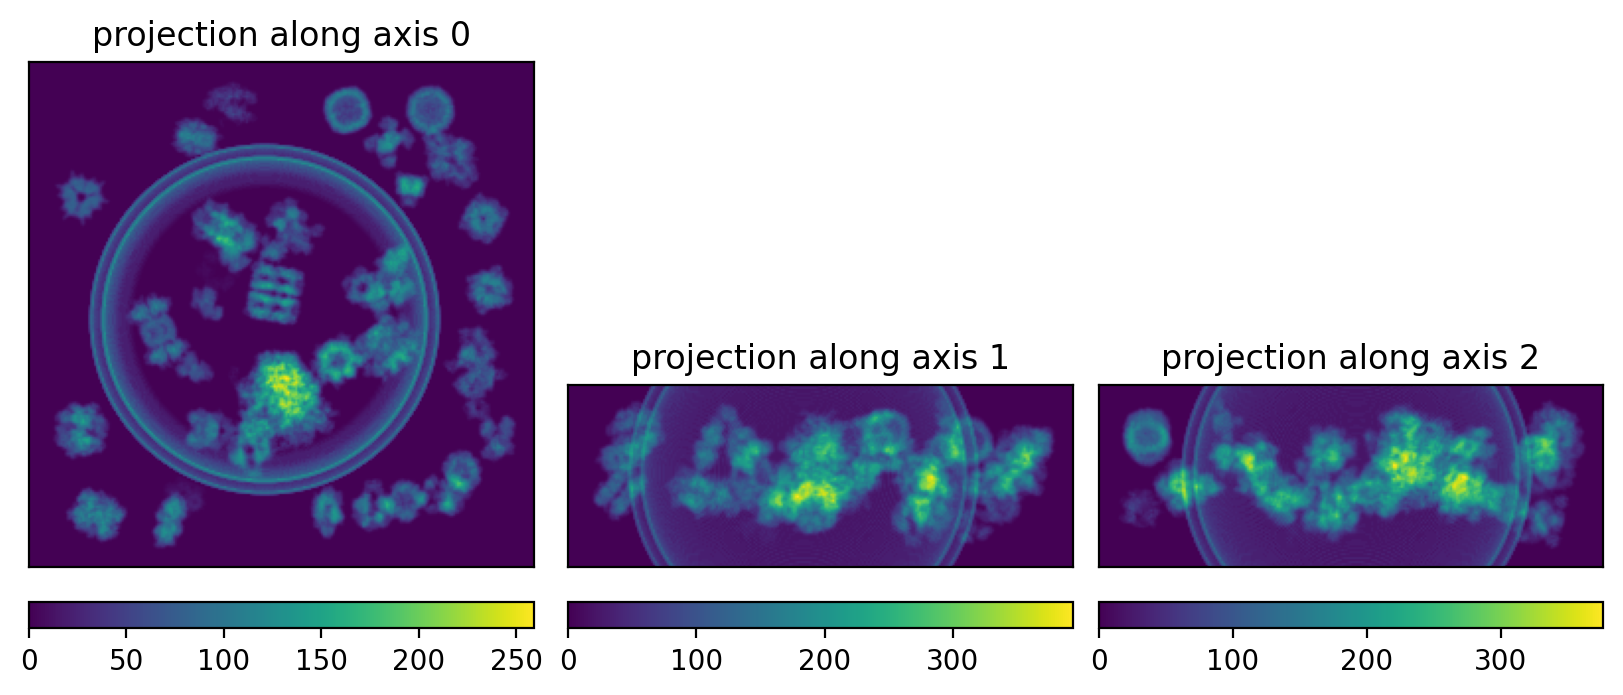

In [7]:
plot3d(volume)

## Simulate a tilt series

`TiltSeriesGenerator` takes the assembled `volume` directly (reshaped to its expected
`(1, Z, Y, X)`), blends in amorphous ice, then simulates the real acquisition: multislice
scattering per tilt angle, CTF, dose, detector MTF, and Poisson shot noise — reconstruction-facing
artifacts like the missing wedge come from the tilt range itself (real reconstruction still has
to happen downstream, e.g. IMOD, since this class only simulates the forward tilt series).

`ice_model="gd"` uses `IceBank`, which samples from the bundled cache of pre-generated,
physically-relaxed ice configs (`ice-data/ice_cache`) rather than generating fresh ice on the
spot — this is the realistic option; `"random"` is a cheap/fast placeholder with no real physical
structure, useful only for quick smoke tests.

`micrograph_size` and `pixel_size` are read from `config`/the generated `volume` rather than
hardcoded, so this cell adapts automatically if you change `target_shape`/`target_v_size` in
`tilt_series.toml`.

In [25]:
micrograph_size = (
    config.micrograph_size
    if config.micrograph_size is not None
    else int(volume.shape[-1])
)
pixel_size = config.target_v_size

angles = torch.linspace(config.min_tilt_angle, config.max_tilt_angle, config.n_tilts)

cs_angstrom = config.cs * 1e7  # mm -> Å
cc_angstrom = config.cc * 1e7 if config.cc is not None else None

ctf_params = {
    "cs": torch.tensor([cs_angstrom]),
    "dfu": torch.tensor([config.defocus]),
}

ice_model = None if config.ice_model == "none" else config.ice_model
# ice_model = None
noise_model = None if config.noise_model == "none" else config.noise_model
# noise_model = None
detector_model = None if config.detector_model == "none" else config.detector_model

tilt_series_gen = TiltSeriesGenerator(
    vol=volume.unsqueeze(0),  # (1, Z, Y, X)
    micrograph_size=micrograph_size,
    pixel_size=pixel_size,
    ctf_params=ctf_params,
    energy=config.energy,
    dose_per_angstrom=config.dose_per_tilt,
    angles=angles,
    ice_model=ice_model,
    ice_cache_dir=config.ice_cache_dir,
    # ice_relax_steps=config.ice_relax_steps,
    ice_relax_steps=2,
    scattering_model=config.scattering_model,
    aberration_model=config.aberration_model,
    noise_model=noise_model,
    alpha=config.alpha,
    pad_fft=config.pad_fft,
    tilt_axis=config.tilt_axis,
    coincidence_radius=config.coincidence_radius,
    num_frames=config.num_frames,
    convergence_angle=config.convergence_angle,
    cc=cc_angstrom,
    energy_spread=config.energy_spread,
    deltaV_V=config.deltaV_V,
    deltaI_I=config.deltaI_I,
    dose_envelope=config.dose_envelope,
    detector_model=detector_model,
)

[TiltSeriesGenerator] Adding ice to volume using gd model


Tiling ice volume: 00:00

Placing ice tiles:   0%|          | 0/50 [00:00<?, ?it/s]

Relaxing tile seams:   0%|          | 0/2 [00:00<?, ?it/s]

[TiltSeriesGenerator] Volume XY too small for requested tilt coverage; padded (reflect) from 256 to 472 px in XY.
  micrograph_size=256, requested_max_tilt=45.00 deg, required_volume_nxy>=455, edge_margin=8 (-> required_nxy_padded>=471).


In [26]:
config.pad_fft

True

In [27]:
device = config.device
tilt_series_gen = tilt_series_gen.to(device)

t0 = time.time()
tilt_series, exitwaves, clean_images = tilt_series_gen.generate_tilt_series(
    torch.tensor([0])
)
print(f"generated in {time.time() - t0:.1f}s")
tilt_series.shape

Generating tilt series.:   0%|          | 0/5 [00:00<?, ?it/s]

Multislice (Iterative):   0%|          | 0/399 [00:00<?, ?it/s]

Multislice (Iterative):   0%|          | 0/266 [00:00<?, ?it/s]

Multislice (Iterative):   0%|          | 0/92 [00:00<?, ?it/s]

Multislice (Iterative):   0%|          | 0/266 [00:00<?, ?it/s]

Multislice (Iterative):   0%|          | 0/399 [00:00<?, ?it/s]

generated in 0.8s


torch.Size([1, 5, 256, 256])

## Visualize the tilt series

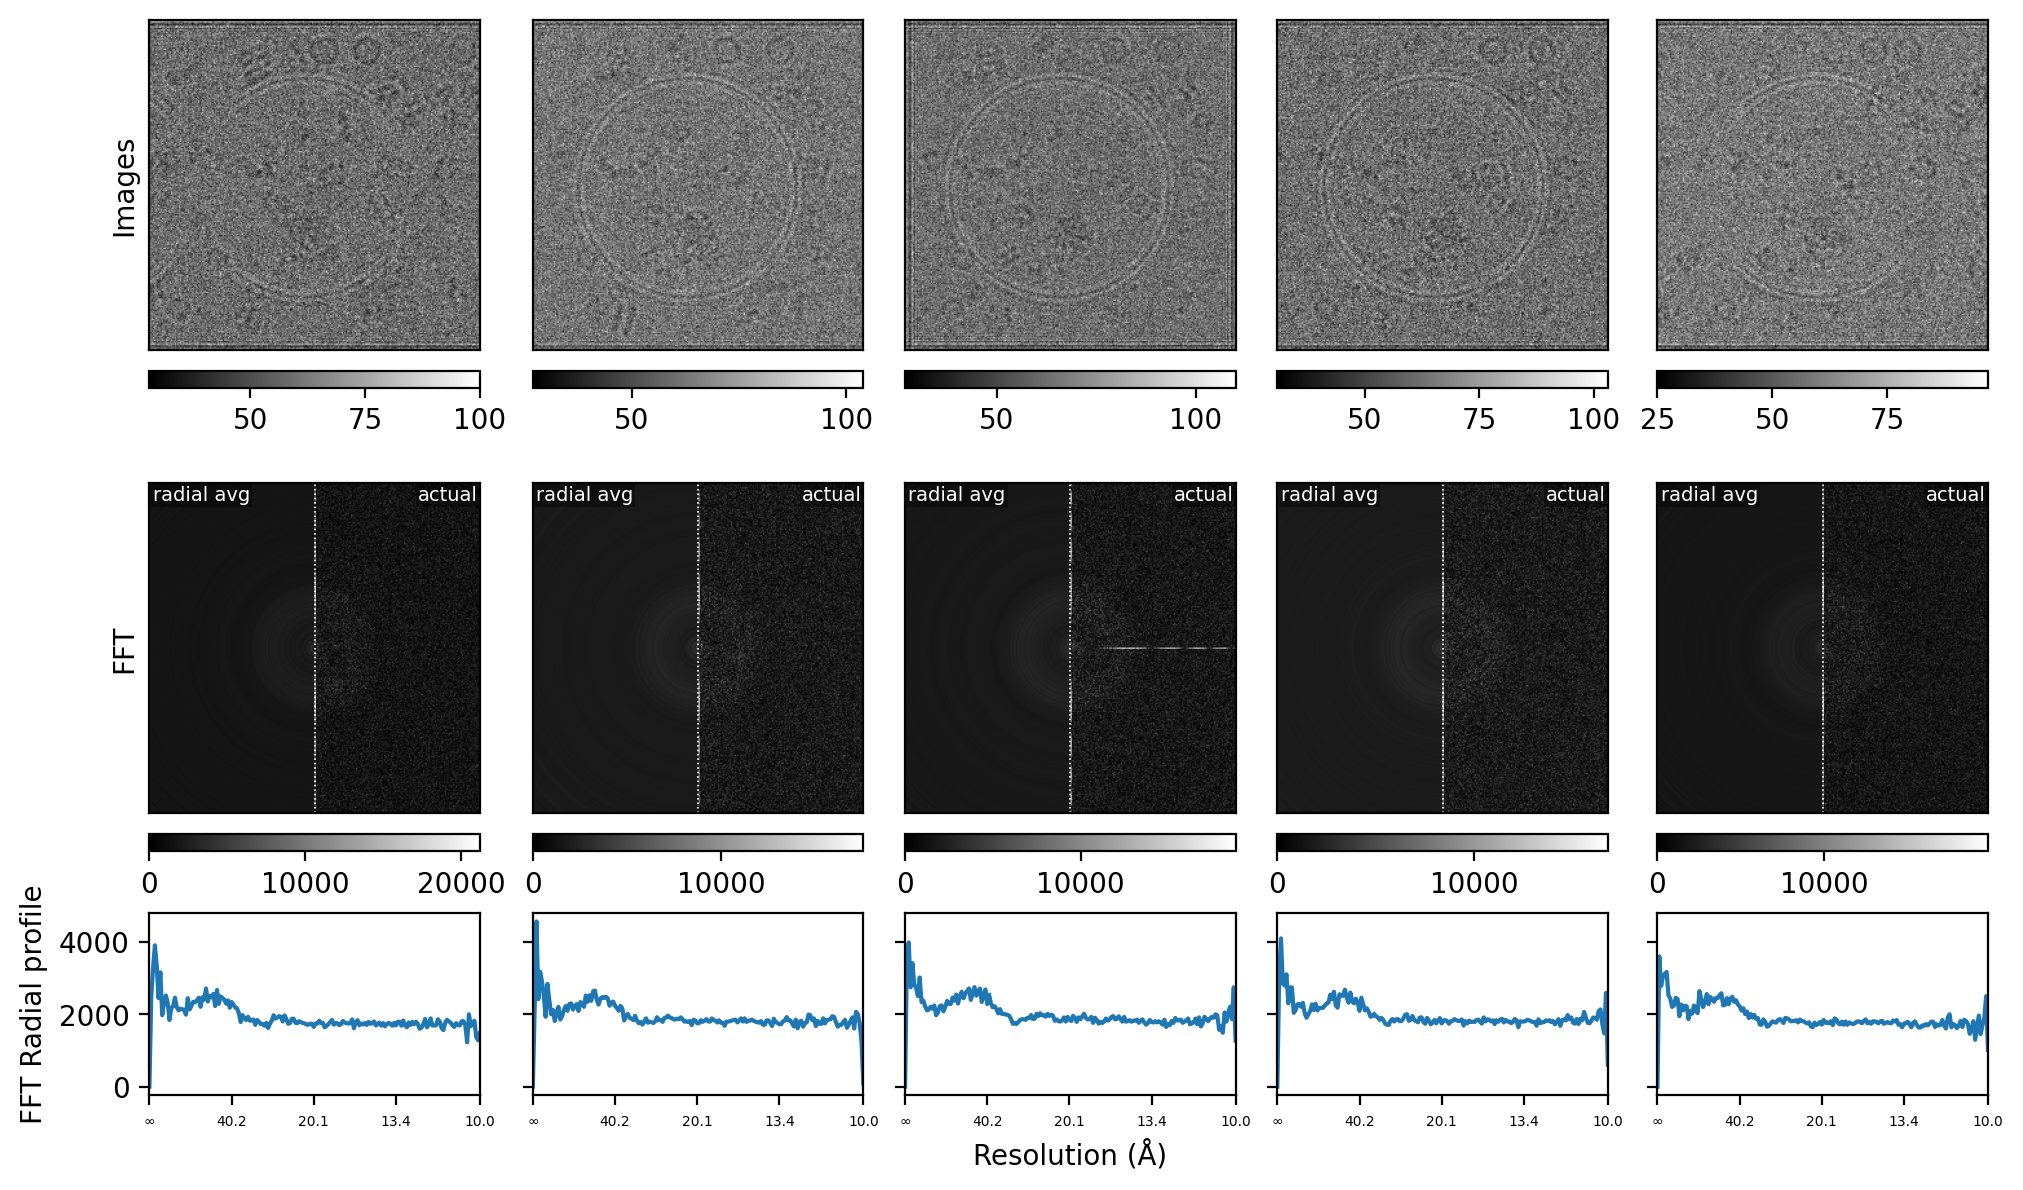

In [28]:
tilt_series_cpu = tilt_series[0].cpu()  # (n_tilts, H, W)

plot_particle_stack(tilt_series_cpu, config.target_v_size)